# Ellipse NaN Analysis

**Updated for `upper_limit=150`** — raising the library's upscaling limit from 100 → 150
rescued ~1 195 sources (15.7%) that previously produced all-NaN vectors.  The remaining
**210 sources (2.8%)** still fail and are studied in Section 5.

This notebook investigates:
1. **How many sources fail** and what fraction they represent
2. **Label / tier bias** — are high-interest (Tier 4) sources over-represented among NaN sources?
3. **Visual inspection** — what do NaN sources look like vs non-NaN sources?
4. **Which percentile threshold is the bottleneck** — can we recover sources by relaxing the 90th-percentile threshold?
5. **The remaining 210 NaN sources** — gallery and statistics after `upper_limit=150`

Root cause: `EllipseFitFeatures` fits ellipses at 6 thresholds `[90, 80, 70, 60, 50, 0]`.
If ANY single threshold fails (no contour, or contour < 5 points), the entire 30-feature vector
is set to NaN (line 499–500 of `astronomaly/feature_extraction/shape_features.py`).

`upper_limit=150` triggers a built-in upscaling retry for sources whose innermost contour has
< 5 points, but sources that produce no contour at all (too faint / point-like) still fail.

## Section 1 — Setup & NaN summary

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from scipy import stats

sys.path.insert(0, str(Path('..').resolve()))
from src.suplat.utils.class_weights import LABEL_COLS, TIERS

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

DATA_DIR  = Path('../data')
OUT_DIR   = Path('../outputs/figures/ellipse_nan_analysis')
CACHE_DIR = Path('../outputs/anomaly_baselines/_ell_cache_42')
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Load images and labels
images = np.load(DATA_DIR / 'preprocessed/lotss/images_filtered.npy')
labels = np.load(DATA_DIR / 'preprocessed/lotss/labels_filtered.npy')
csv    = pd.read_csv(DATA_DIR / 'metadata/lotss_classifications_horton_et_al_2025_filtered.csv')

print(f'Images : {images.shape}  dtype={images.dtype}')
print(f'Labels : {labels.shape}  dtype={labels.dtype}')
print(f'CSV    : {csv.shape}')
print(f'LABEL_COLS: {LABEL_COLS}')

Images : (7596, 89, 89)  dtype=uint8
Labels : (7596, 20)  dtype=int8
CSV    : (7596, 36)
LABEL_COLS: ['fri', 'frii', 'hybrid', 'spiral', 'relaxed', 'cshaped', 'sshaped', 'misaligned', 'wings', 'xshaped', 'straight', 'multihotspots', 'continuous', 'banding', 'onesided', 'restarted', 'cluster', 'merger', 'diffuse', 'unknown']


In [3]:
# Load cached ellipse features (avoids slow re-extraction)
_all_ell = pd.read_parquet(CACHE_DIR / 'EllipseFitFeatures_output.parquet')
print(f'Ellipse features shape: {_all_ell.shape}')
print(f'Columns: {list(_all_ell.columns[:6])} ... ({len(_all_ell.columns)} total)')
_all_ell.head(3)

Ellipse features shape: (7596, 30)
Columns: ['Residual_90', 'Residual_80', 'Residual_70', 'Residual_60', 'Residual_50', 'Residual_0'] ... (30 total)


,Residual_90,Residual_80,Residual_70,Residual_60,Residual_50,Residual_0,Offset_90,Offset_80,Offset_70,Offset_60,...,Theta_70,Theta_60,Theta_50,Theta_0,Maj_90,Maj_80,Maj_70,Maj_60,Maj_50,Maj_0
0,0.059462,0.091781,0.144552,0.219417,0.306653,0.250726,0.0,2.404239,7.139001,2.635929,...,2.599472,0.551712,2.311203,3.544403,2.393445,2.633515,1.996792,1.596368,1.305094,1.135059
1,0.020957,0.081303,0.083702,0.188234,0.140891,0.154021,0.0,16.714901,16.664909,17.004350,...,22.080917,33.624836,30.984463,23.589352,2.742184,3.180061,3.376689,1.804012,1.868048,1.391371
2,0.094433,0.103901,0.351471,0.001515,0.368135,0.158818,0.0,4.814635,13.495813,6.740987,...,19.092936,27.823225,24.156309,68.162043,2.588368,2.530272,1.501206,2.659454,1.267859,1.070904


In [4]:
# Identify NaN sources
nan_mask = _all_ell.isna().any(axis=1).values

N_total = len(nan_mask)
N_nan   = nan_mask.sum()
N_ok    = N_total - N_nan
frac_nan = N_nan / N_total

print(f'Total sources  : {N_total}')
print(f'NaN sources    : {N_nan}  ({frac_nan:.1%})')
print(f'Valid sources  : {N_ok}  ({1 - frac_nan:.1%})')

Total sources  : 7596
NaN sources    : 1407  (18.5%)
Valid sources  : 6189  (81.5%)


## Section 2 — Label & tier bias

For each of the 20 label columns, compute the fraction of sources in that class that have
NaN ellipse features. Compare against the overall NaN rate (~18.5%).

In [5]:
# Per-class NaN rate
label_arr = labels.astype(bool)  # (N, 20)

class_nan_rates = {}
class_counts    = {}
for i, col in enumerate(LABEL_COLS):
    mask_class = label_arr[:, i]
    n_class = mask_class.sum()
    n_nan_in_class = (mask_class & nan_mask).sum()
    class_nan_rates[col] = n_nan_in_class / n_class if n_class > 0 else np.nan
    class_counts[col] = n_class

df_rates = pd.DataFrame({'class': list(LABEL_COLS),
                          'nan_rate': [class_nan_rates[c] for c in LABEL_COLS],
                          'count': [class_counts[c] for c in LABEL_COLS]})
df_rates = df_rates.sort_values('nan_rate', ascending=False).reset_index(drop=True)
print(df_rates.to_string(index=False))

        class  nan_rate  count
     straight  0.466418    268
     onesided  0.315789     19
      relaxed  0.303621    359
multihotspots  0.247826   1610
   misaligned  0.210577   1040
      sshaped  0.209491    864
    restarted  0.208054    149
         frii  0.203245   4684
      diffuse  0.189189     74
      cshaped  0.182869   1903
      banding  0.177083     96
        wings  0.173742   1272
   continuous  0.161290    279
          fri  0.149813   2403
       hybrid  0.133690    748
      xshaped  0.114865    148
       merger  0.102041     49
      unknown  0.070707     99
      cluster  0.055556     54
       spiral  0.020833    144


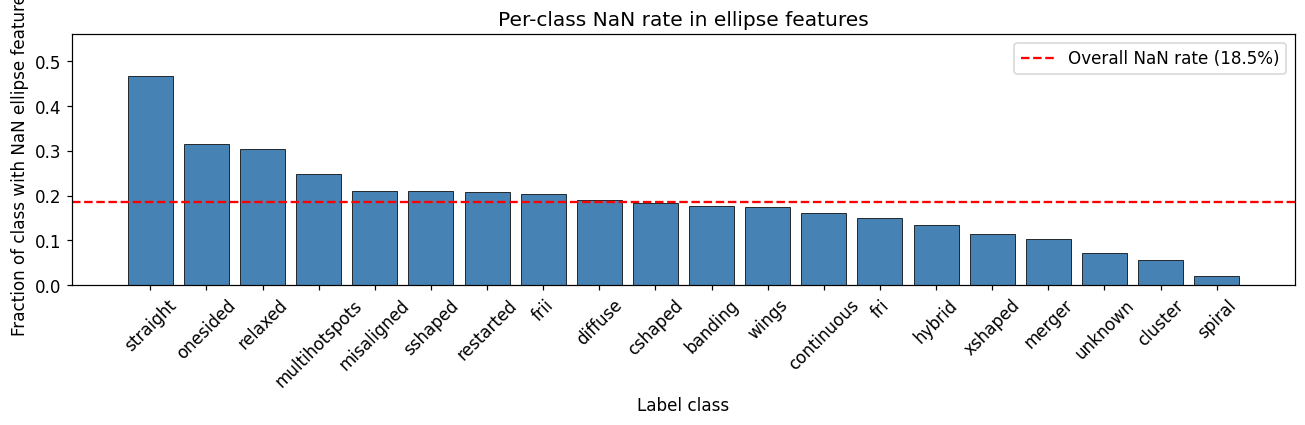

In [6]:
# Bar chart of NaN rate per class
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(df_rates['class'], df_rates['nan_rate'], color='steelblue', edgecolor='k', linewidth=0.5)
ax.axhline(frac_nan, color='red', linestyle='--', linewidth=1.5, label=f'Overall NaN rate ({frac_nan:.1%})')
ax.set_xlabel('Label class')
ax.set_ylabel('Fraction of class with NaN ellipse features')
ax.set_title('Per-class NaN rate in ellipse features')
ax.set_ylim(0, min(1.0, df_rates['nan_rate'].max() * 1.2))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'per_class_nan_rate.png', dpi=150)
plt.show()

In [7]:
# Tier-level NaN rates
# Assign each source to its highest tier
tier_scores = np.zeros(N_total, dtype=int)
for tier_val, cols in TIERS:
    col_idxs = [LABEL_COLS.index(c) for c in cols]
    in_tier = label_arr[:, col_idxs].any(axis=1)
    tier_scores[in_tier] = tier_val  # overwrites with highest tier since TIERS is [(4,...),(3,...),..]

# Actually we want the MAX tier per source — iterate from lowest to highest
tier_scores = np.zeros(N_total, dtype=int)
for tier_val, cols in reversed(TIERS):  # 1, 2, 3, 4
    col_idxs = [LABEL_COLS.index(c) for c in cols]
    in_tier = label_arr[:, col_idxs].any(axis=1)
    tier_scores[in_tier] = tier_val

print('Tier distribution:', np.bincount(tier_scores))

tier_results = []
for t in [1, 2, 3, 4]:
    mask_tier = tier_scores == t
    n_tier = mask_tier.sum()
    n_nan_tier = (mask_tier & nan_mask).sum()
    rate = n_nan_tier / n_tier if n_tier > 0 else np.nan
    tier_results.append({'tier': t, 'n_sources': n_tier, 'n_nan': n_nan_tier, 'nan_rate': rate})

df_tiers = pd.DataFrame(tier_results)
print()
print(df_tiers.to_string(index=False))

Tier distribution: [ 128 2685 3480 1018  285]

 tier  n_sources  n_nan  nan_rate
    1       2685    444  0.165363
    2       3480    723  0.207759
    3       1018    186  0.182711
    4        285     28  0.098246


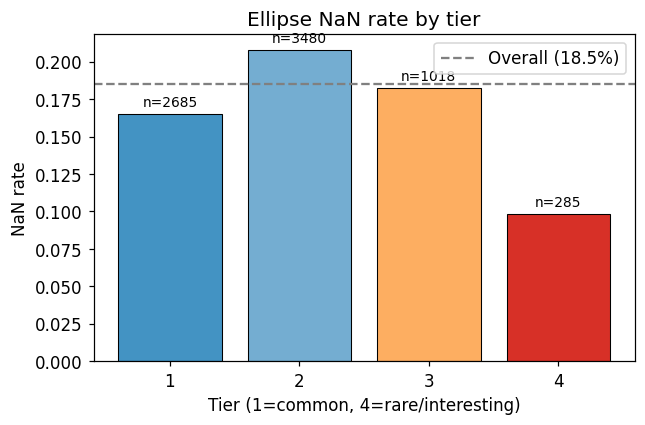

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
tier_colors = ['#4393c3', '#74add1', '#fdae61', '#d73027']
bars = ax.bar(df_tiers['tier'], df_tiers['nan_rate'],
              color=tier_colors, edgecolor='k', linewidth=0.7)
ax.axhline(frac_nan, color='gray', linestyle='--', linewidth=1.5,
           label=f'Overall ({frac_nan:.1%})')
for bar, row in zip(bars, tier_results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'n={row["n_sources"]}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Tier (1=common, 4=rare/interesting)')
ax.set_ylabel('NaN rate')
ax.set_title('Ellipse NaN rate by tier')
ax.set_xticks([1, 2, 3, 4])
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'tier_nan_rate.png', dpi=150)
plt.show()

In [9]:
# Chi-squared test: is NaN rate significantly different across tiers?
observed_nan = df_tiers['n_nan'].values
observed_ok  = (df_tiers['n_sources'] - df_tiers['n_nan']).values

contingency = np.array([observed_nan, observed_ok])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f'Chi-squared test (NaN membership vs tier):')
print(f'  chi2={chi2:.3f}, dof={dof}, p={p_val:.4f}')
if p_val < 0.05:
    print('  => Statistically significant tier bias (p < 0.05)')
else:
    print('  => No significant tier bias (p >= 0.05)')

Chi-squared test (NaN membership vs tier):
  chi2=33.094, dof=3, p=0.0000
  => Statistically significant tier bias (p < 0.05)


## Section 3 — Image gallery of NaN vs non-NaN sources

Hypothesis: NaN sources are faint, point-like, or have low dynamic range, so the
90th-percentile threshold clips all non-zero pixels.

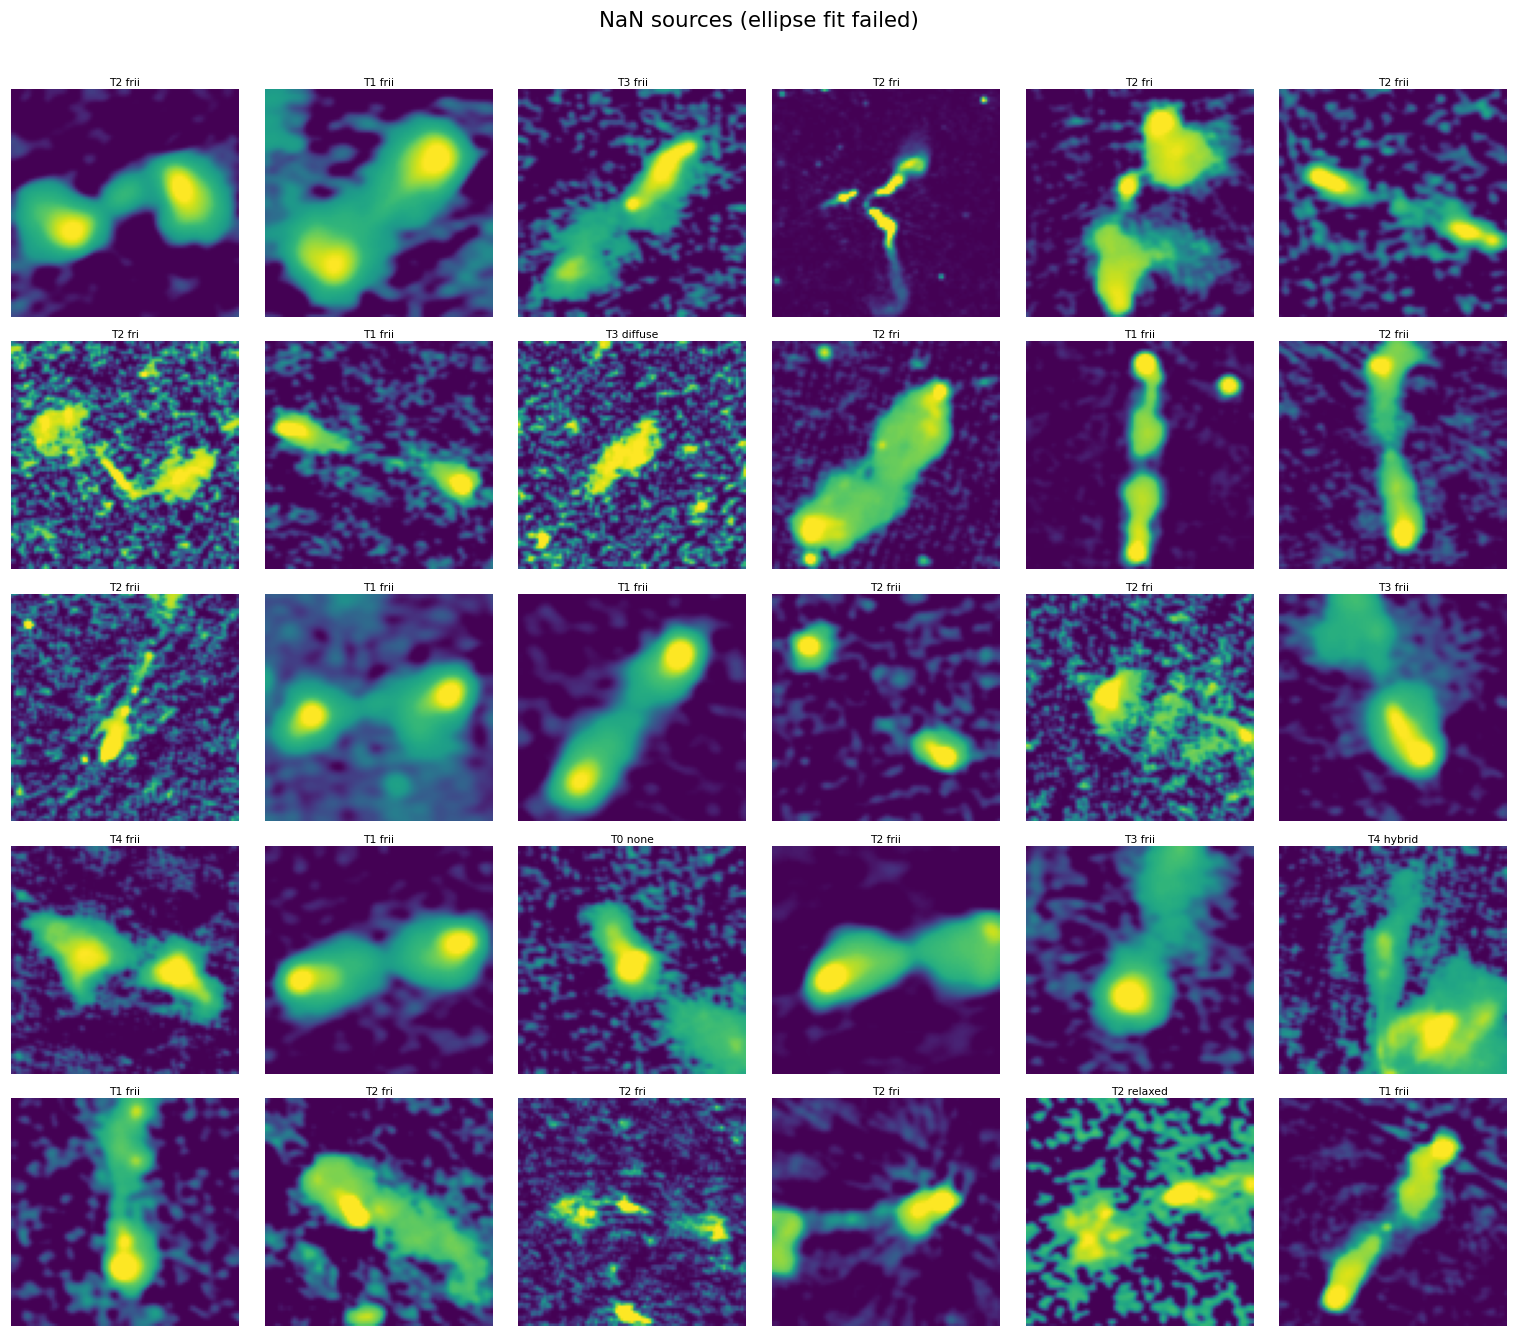

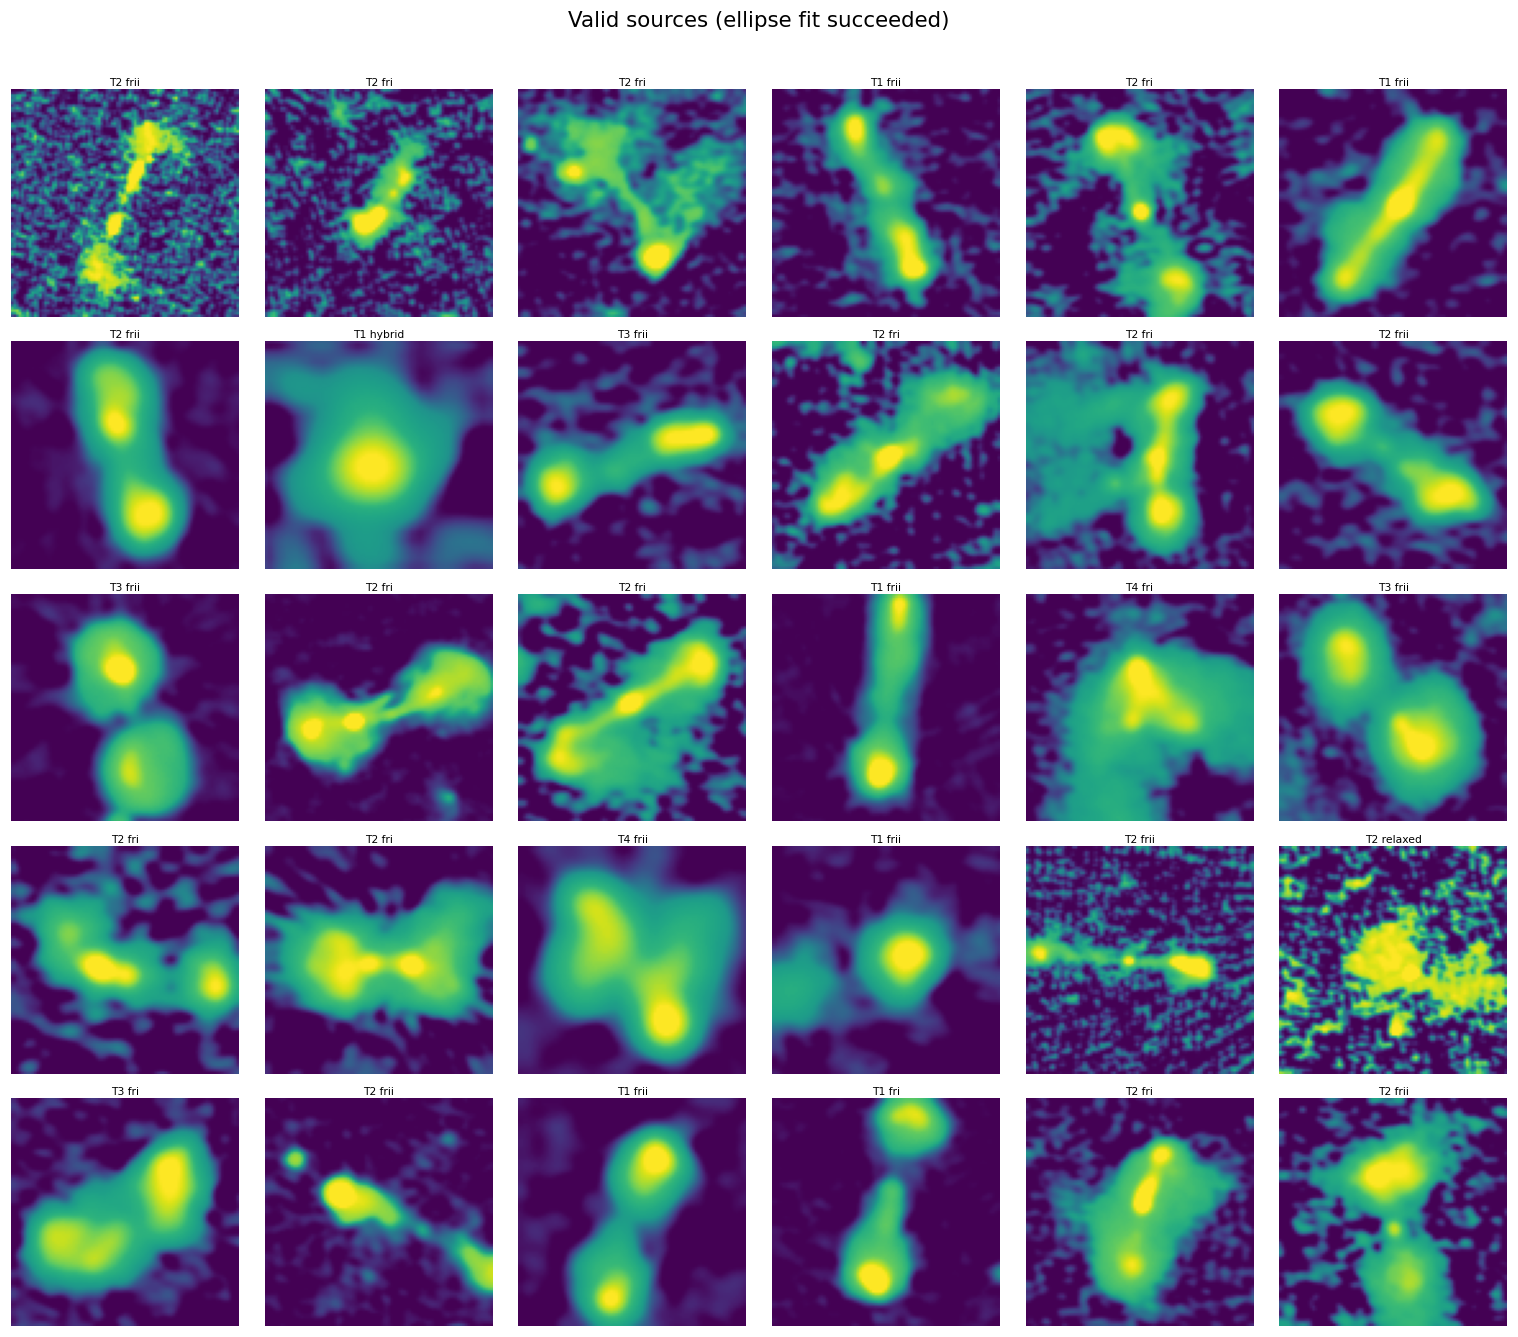

In [10]:
rng = np.random.default_rng(42)

nan_idxs = np.where(nan_mask)[0]
ok_idxs  = np.where(~nan_mask)[0]

n_rows, n_cols = 5, 6
sample_nan = rng.choice(nan_idxs, size=n_rows * n_cols, replace=False)
sample_ok  = rng.choice(ok_idxs,  size=n_rows * n_cols, replace=False)

def get_tier_label(idx):
    t = tier_scores[idx]
    # Get first positive label for display
    pos = np.where(label_arr[idx])[0]
    first_label = LABEL_COLS[pos[0]] if len(pos) > 0 else 'none'
    return f'T{t} {first_label}'

def plot_gallery(idxs, title, fname):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 12))
    fig.suptitle(title, fontsize=14, y=1.01)
    for ax, idx in zip(axes.flat, idxs):
        im = images[idx]
        ax.imshow(im, cmap='viridis', origin='lower',
                  vmin=np.percentile(im, 1), vmax=np.percentile(im, 99))
        ax.set_title(get_tier_label(idx), fontsize=7, pad=2)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(OUT_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()

plot_gallery(sample_nan, 'NaN sources (ellipse fit failed)', 'gallery_nan.png')
plot_gallery(sample_ok,  'Valid sources (ellipse fit succeeded)', 'gallery_ok.png')

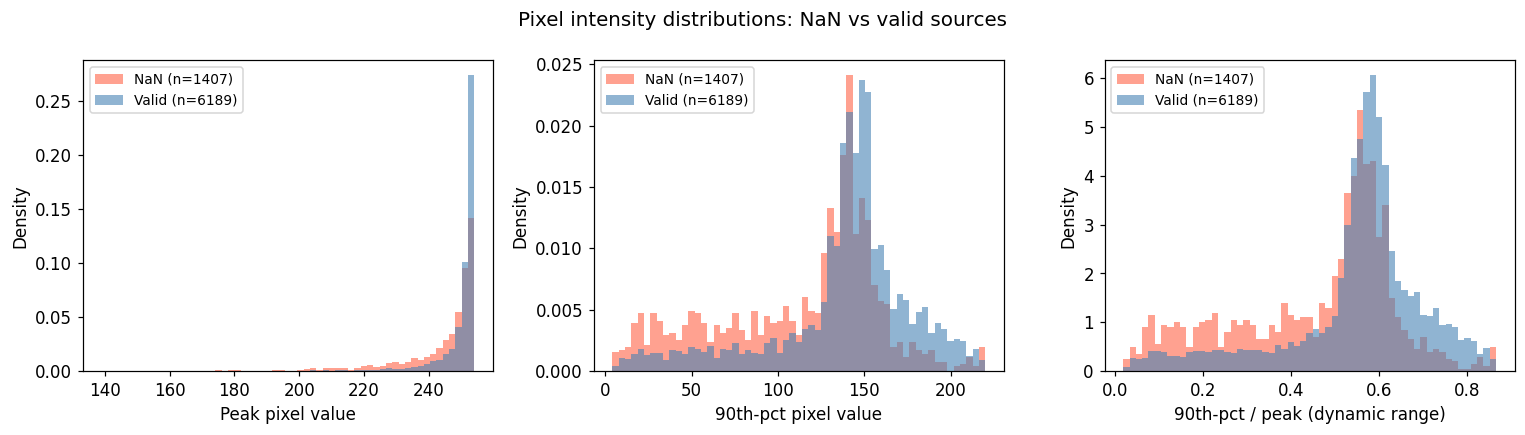

KS test (peak): statistic=0.2672, p=1.34e-72
KS test (p90): statistic=0.2569, p=4.68e-67
KS test (dynrange): statistic=0.2426, p=8.83e-60


In [11]:
# Compare pixel intensity statistics: NaN vs non-NaN sources
# Peak brightness and 90th-percentile pixel value
peak_nan = images[nan_idxs].max(axis=(1, 2))
peak_ok  = images[ok_idxs].max(axis=(1, 2))
p90_nan  = np.percentile(images[nan_idxs], 90, axis=(1, 2))
p90_ok   = np.percentile(images[ok_idxs],  90, axis=(1, 2))
# Dynamic range: p90 / peak (how close p90 is to peak)
dynrange_nan = p90_nan / np.clip(peak_nan, 1e-10, None)
dynrange_ok  = p90_ok  / np.clip(peak_ok,  1e-10, None)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, arr_nan, arr_ok, xlabel, fname_suf in zip(
        axes,
        [peak_nan, p90_nan, dynrange_nan],
        [peak_ok,  p90_ok,  dynrange_ok],
        ['Peak pixel value', '90th-pct pixel value', '90th-pct / peak (dynamic range)'],
        ['peak', 'p90', 'dynrange']):
    bins = np.linspace(min(arr_nan.min(), arr_ok.min()),
                       max(np.percentile(arr_nan, 99), np.percentile(arr_ok, 99)), 60)
    ax.hist(arr_nan, bins=bins, alpha=0.6, label=f'NaN (n={len(arr_nan)})', density=True, color='tomato')
    ax.hist(arr_ok,  bins=bins, alpha=0.6, label=f'Valid (n={len(arr_ok)})', density=True, color='steelblue')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

fig.suptitle('Pixel intensity distributions: NaN vs valid sources', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'intensity_distributions.png', dpi=150)
plt.show()

# KS test
for arr_nan, arr_ok, label in [(peak_nan, peak_ok, 'peak'), (p90_nan, p90_ok, 'p90'), (dynrange_nan, dynrange_ok, 'dynrange')]:
    ks, p = stats.ks_2samp(arr_nan, arr_ok)
    print(f'KS test ({label}): statistic={ks:.4f}, p={p:.2e}')

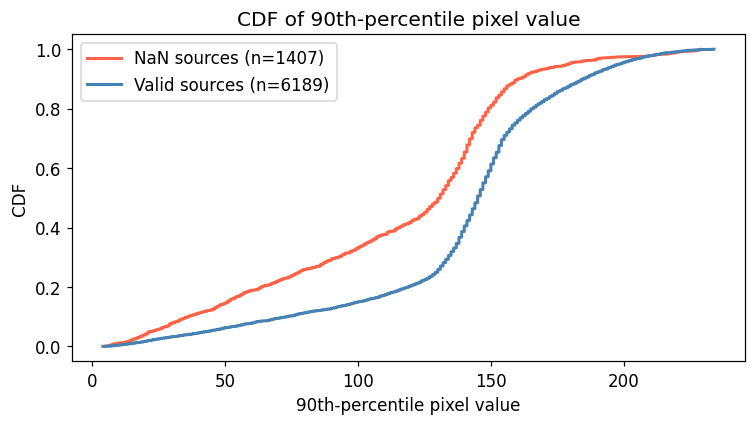

In [12]:
# CDF of 90th-percentile pixel values: shows why faint sources fail at 90th-pct threshold
fig, ax = plt.subplots(figsize=(7, 4))
for arr, label, color in [(p90_nan, 'NaN sources', 'tomato'), (p90_ok, 'Valid sources', 'steelblue')]:
    sorted_arr = np.sort(arr)
    cdf = np.arange(1, len(sorted_arr) + 1) / len(sorted_arr)
    ax.plot(sorted_arr, cdf, label=f'{label} (n={len(arr)})', color=color, linewidth=2)
ax.set_xlabel('90th-percentile pixel value')
ax.set_ylabel('CDF')
ax.set_title('CDF of 90th-percentile pixel value')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'p90_cdf.png', dpi=150)
plt.show()

## Section 4 — Per-percentile failure analysis

For a random sample of NaN sources, re-run contour detection one threshold at a time
to identify which percentile causes the FIRST failure.

Failure conditions (mirroring `shape_features.py`):
- No contours found at a given threshold → `failed = True`
- Closest contour has < 5 points → early `break`

The images are 89×89, and `EllipseFitFeatures` checks
`np.percentile(resize[resize > 0], p)` for each percentile `p` in `[90, 80, 70, 60, 50, 0]`.

In [13]:
PERCENTILES = [90, 80, 70, 60, 50, 0]  # order from shape_features.py (sorted descending)

def find_contours_at_thresh(image, thresh):
    """Replicate astronomaly's find_contours logic."""
    # astronomaly normalises to uint8 for cv2
    img_norm = image.copy()
    if img_norm.max() > 0:
        img_norm = img_norm / img_norm.max()
    thresh_norm = thresh / image.max() if image.max() > 0 else thresh
    img_uint8 = (img_norm * 255).astype(np.uint8)
    thresh_uint8 = int(thresh_norm * 255)
    _, binary = cv2.threshold(img_uint8, thresh_uint8, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
    return contours

def first_failure_percentile(image, percentiles=PERCENTILES):
    """Return the first percentile that fails for this image, or None if all pass."""
    if image.max() == 0:
        return 'all_zero'
    
    pos_pixels = image[image > 0]
    x_cent = image.shape[0] // 2
    y_cent = image.shape[1] // 2
    x0 = y0 = -1
    
    for p in sorted(percentiles, reverse=True):
        if len(pos_pixels) == 0:
            return p
        thresh = np.percentile(pos_pixels, p)
        contours = find_contours_at_thresh(image, thresh)
        
        if len(contours) == 0:
            return p
        
        # Find closest contour to centre (mirroring astronomaly)
        x_cs = np.array([cv2.moments(c)["m10"] / max(cv2.moments(c)["m00"], 1e-10) for c in contours])
        y_cs = np.array([cv2.moments(c)["m01"] / max(cv2.moments(c)["m00"], 1e-10) for c in contours])
        ref_x = x0 if x0 != -1 else x_cent
        ref_y = y0 if y0 != -1 else y_cent
        r = np.sqrt((x_cs - ref_x)**2 + (y_cs - ref_y)**2)
        ind = np.argmin(r)
        c = contours[ind]
        
        if x0 == -1:
            x0 = x_cs[ind]
            y0 = y_cs[ind]
        
        if len(c) < 5:
            return p
    
    return None  # all percentiles passed

print('Testing failure detection on a few NaN sources...')
for idx in nan_idxs[:5]:
    fail_at = first_failure_percentile(images[idx])
    print(f'  source {idx}: first failure at percentile {fail_at}')

Testing failure detection on a few NaN sources...
  source 4: first failure at percentile 80
  source 9: first failure at percentile 80
  source 10: first failure at percentile None
  source 11: first failure at percentile None
  source 19: first failure at percentile 80


In [14]:
# Run on a random sample of 200 NaN sources
SAMPLE_SIZE = min(200, len(nan_idxs))
sample_nan_200 = rng.choice(nan_idxs, size=SAMPLE_SIZE, replace=False)

failure_at = []
for i, idx in enumerate(sample_nan_200):
    fail_p = first_failure_percentile(images[idx])
    failure_at.append('all_pass' if fail_p is None else str(fail_p))
    if (i + 1) % 50 == 0:
        print(f'  Processed {i+1}/{SAMPLE_SIZE}')

failure_at = np.array(failure_at, dtype=str)
print('\nFirst-failure distribution:')
unique, counts = np.unique(failure_at, return_counts=True)
for u, c in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f'  pct={u}: {c} sources ({c/SAMPLE_SIZE:.1%})')

  Processed 50/200
  Processed 100/200
  Processed 150/200
  Processed 200/200

First-failure distribution:
  pct=all_pass: 61 sources (30.5%)
  pct=70: 33 sources (16.5%)
  pct=60: 29 sources (14.5%)
  pct=80: 26 sources (13.0%)
  pct=90: 21 sources (10.5%)
  pct=50: 17 sources (8.5%)
  pct=0: 13 sources (6.5%)


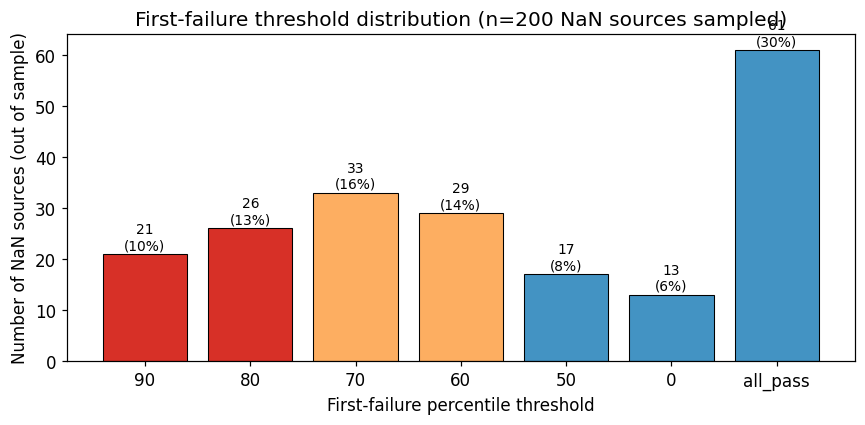


Sources failing first at 90th percentile: 21 (10.5%)
=> Relaxing/removing the 90th-percentile threshold would recover these sources.


In [15]:
# Bar chart of first-failure percentile
categories = [str(p) for p in PERCENTILES] + ['all_pass', 'all_zero']
counts_dict = {str(u): c for u, c in zip(unique, counts)}
bar_counts  = [counts_dict.get(cat, 0) for cat in categories]

# Filter to only categories with at least 1 occurrence
cat_labels = [c for c, v in zip(categories, bar_counts) if v > 0]
cat_values = [v for v in bar_counts if v > 0]

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ['#d73027' if c in ['90', '80'] else '#fdae61' if c in ['70', '60']
              else '#4393c3' for c in cat_labels]
bars = ax.bar(cat_labels, cat_values, color=bar_colors, edgecolor='k', linewidth=0.7)
for bar, val in zip(bars, cat_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}\n({val/SAMPLE_SIZE:.0%})', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('First-failure percentile threshold')
ax.set_ylabel('Number of NaN sources (out of sample)')
ax.set_title(f'First-failure threshold distribution (n={SAMPLE_SIZE} NaN sources sampled)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'first_failure_threshold.png', dpi=150)
plt.show()

# Interpretation
pct90_count = counts_dict.get('90', 0)
print(f'\nSources failing first at 90th percentile: {pct90_count} ({pct90_count/SAMPLE_SIZE:.1%})')
print('=> Relaxing/removing the 90th-percentile threshold would recover these sources.')

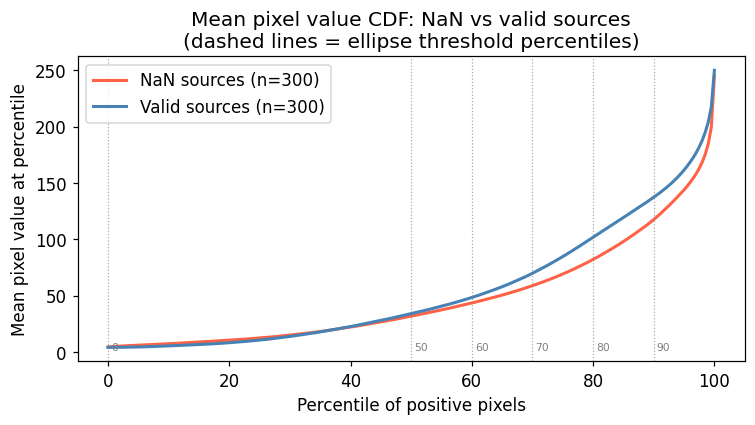

In [16]:
# Compare pixel CDFs: NaN vs valid sources
# This shows why sparse images fail at high percentile thresholds
n_sample_cdf = min(300, len(nan_idxs), len(ok_idxs))
sample_nan_cdf = rng.choice(nan_idxs, size=n_sample_cdf, replace=False)
sample_ok_cdf  = rng.choice(ok_idxs,  size=n_sample_cdf, replace=False)

# Mean CDF over sampled sources
def mean_cdf(imgs_subset, n_bins=200):
    all_flat = []
    for img in imgs_subset:
        pos = img[img > 0]
        if len(pos) > 0:
            all_flat.append(np.percentile(pos, np.linspace(0, 100, n_bins)))
    return np.mean(all_flat, axis=0)

x_ax   = np.linspace(0, 100, 200)
cdf_nan = mean_cdf(images[sample_nan_cdf])
cdf_ok  = mean_cdf(images[sample_ok_cdf])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_ax, cdf_nan, color='tomato', linewidth=2, label=f'NaN sources (n={n_sample_cdf})')
ax.plot(x_ax, cdf_ok,  color='steelblue', linewidth=2, label=f'Valid sources (n={n_sample_cdf})')
for pct in PERCENTILES:
    ax.axvline(pct, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
    ax.text(pct + 0.5, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0,
            str(pct), fontsize=7, color='gray', va='bottom')
ax.set_xlabel('Percentile of positive pixels')
ax.set_ylabel('Mean pixel value at percentile')
ax.set_title('Mean pixel value CDF: NaN vs valid sources\n(dashed lines = ellipse threshold percentiles)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'pixel_cdf_comparison.png', dpi=150)
plt.show()

In [17]:
# Summary
print('=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'Total sources         : {N_total}')
print(f'NaN ellipse features  : {N_nan} ({frac_nan:.1%})')
print()
print('Tier NaN rates:')
for row in tier_results:
    print(f"  Tier {row['tier']}: {row['nan_rate']:.1%} (n={row['n_sources']})")
print(f'Chi-sq p-value (tier bias): {p_val:.4f}')
print()
pct90_count = counts_dict.get('90', 0)
print(f'First-failure at pct=90 : {pct90_count}/{SAMPLE_SIZE} ({pct90_count/SAMPLE_SIZE:.1%}) of NaN sources')
print()
print('Conclusions:')
if p_val >= 0.05:
    print('- No significant tier bias: NaN rate is approximately uniform across tiers')
else:
    print('- Significant tier bias detected — check tier bars for direction')
if pct90_count / SAMPLE_SIZE > 0.5:
    print('- Majority of NaN failures occur at the 90th-percentile threshold')
    print('  => Dropping or lowering the 90th-pct threshold would recover most NaN sources')
else:
    print('- NaN failures are spread across multiple thresholds')
    print('  => No single threshold dominates — sources may be genuinely too faint/point-like')

SUMMARY
Total sources         : 7596
NaN ellipse features  : 1407 (18.5%)

Tier NaN rates:
  Tier 1: 16.5% (n=2685)
  Tier 2: 20.8% (n=3480)
  Tier 3: 18.3% (n=1018)
  Tier 4: 9.8% (n=285)
Chi-sq p-value (tier bias): 0.0000

First-failure at pct=90 : 21/200 (10.5%) of NaN sources

Conclusions:
- Significant tier bias detected — check tier bars for direction
- NaN failures are spread across multiple thresholds
  => No single threshold dominates — sources may be genuinely too faint/point-like


## Section 5 — Remaining 210 NaN sources after `upper_limit=150`

These are the sources that still fail ellipse fitting even after the upscaling retry.
They are currently handled by median imputation in the pipeline.  The goal here is to
understand whether they share a common failure mode (too faint, point-like, artefacts)
and whether any interesting sources are among them.

In [ ]:
# ── Identify the 210 remaining NaN sources ────────────────────────────────────
# nan_mask and images/labels are already loaded from earlier cells.
# nan_idxs here are the remaining failures under upper_limit=150.
remaining_nan_idxs = np.where(nan_mask)[0]
remaining_ok_idxs  = np.where(~nan_mask)[0]

N_remaining = len(remaining_nan_idxs)
print(f"Remaining NaN sources (upper_limit=150): {N_remaining} / {N_total} "
      f"({N_remaining / N_total:.1%})")
print(f"Valid sources:                           {len(remaining_ok_idxs)} / {N_total}")

# Tier scores for remaining NaN sources
tier_remaining = tier_scores[remaining_nan_idxs]
print(f"\nTier distribution of remaining {N_remaining} NaN sources:")
for t in [0, 1, 2, 3, 4]:
    n = (tier_remaining == t).sum()
    if n > 0:
        pct = n / N_remaining
        print(f"  Tier {t}: {n:3d}  ({pct:.1%})")

# Peak brightness of remaining NaN sources
peak_remaining = images[remaining_nan_idxs].max(axis=(1, 2))
print(f"\nPeak brightness statistics (remaining NaN):")
print(f"  min={peak_remaining.min():.1f}  median={np.median(peak_remaining):.1f}"
      f"  mean={peak_remaining.mean():.1f}  max={peak_remaining.max():.1f}")
print(f"  Sources with peak < 10: {(peak_remaining < 10).sum()}"
      f"  (effectively blank images)")

# Featurecount for remaining NaN sources
fc_remaining = csv['featurecount'].values[remaining_nan_idxs]
print(f"\nFeaturecount statistics (remaining NaN):")
print(f"  min={fc_remaining.min():.0f}  median={np.median(fc_remaining):.0f}"
      f"  mean={fc_remaining.mean():.1f}  max={fc_remaining.max():.0f}")

In [ ]:
# ── Label bias among remaining 210 NaN sources ────────────────────────────────
label_remaining = labels[remaining_nan_idxs].astype(bool)  # (210, 20)
label_valid     = labels[remaining_ok_idxs].astype(bool)   # (7386, 20)

rows = []
for i, col in enumerate(LABEL_COLS):
    n_rem   = label_remaining[:, i].sum()
    n_val   = label_valid[:, i].sum()
    rate_rem = n_rem / N_remaining
    rate_val = n_val / len(remaining_ok_idxs)
    rows.append(dict(label=col, n_remaining=n_rem, rate_remaining=rate_rem,
                     n_valid=n_val, rate_valid=rate_val,
                     rate_ratio=rate_rem / rate_val if rate_val > 0 else np.nan))

df_lab_rem = pd.DataFrame(rows).sort_values('rate_ratio', ascending=False)

fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(len(LABEL_COLS))
df_plot = df_lab_rem.set_index('label').reindex(LABEL_COLS)
ax.bar(x - 0.2, df_plot['rate_remaining'], width=0.38, label=f'Remaining NaN (n={N_remaining})',
       color='tomato', edgecolor='k', linewidth=0.5)
ax.bar(x + 0.2, df_plot['rate_valid'],     width=0.38, label=f'Valid (n={len(remaining_ok_idxs)})',
       color='steelblue', edgecolor='k', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(LABEL_COLS, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Fraction of group with this label')
ax.set_title('Label prevalence: remaining NaN vs valid sources')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'remaining_nan_label_rates.png', dpi=150)
plt.show()

print(df_lab_rem[['label', 'n_remaining', 'rate_remaining', 'rate_valid', 'rate_ratio']]
      .to_string(index=False, float_format='{:.3f}'.format))

In [ ]:
# ── Pixel statistics: remaining NaN vs valid ──────────────────────────────────
peak_valid   = images[remaining_ok_idxs].max(axis=(1, 2))
p90_remaining = np.percentile(images[remaining_nan_idxs], 90, axis=(1, 2))
p90_valid     = np.percentile(images[remaining_ok_idxs],  90, axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, arr_nan, arr_ok, xlabel in zip(
        axes,
        [peak_remaining, p90_remaining],
        [peak_valid,     p90_valid],
        ['Peak pixel value', '90th-pct pixel value']):
    bins = np.linspace(0, max(np.percentile(arr_nan, 99), np.percentile(arr_ok, 99)), 60)
    ax.hist(arr_nan, bins=bins, alpha=0.65, density=True, color='tomato',
            label=f'Remaining NaN (n={N_remaining})')
    ax.hist(arr_ok,  bins=bins, alpha=0.65, density=True, color='steelblue',
            label=f'Valid (n={len(remaining_ok_idxs)})')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

fig.suptitle('Pixel intensity: remaining NaN vs valid sources', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'remaining_nan_pixel_stats.png', dpi=150)
plt.show()

ks_peak, p_peak = stats.ks_2samp(peak_remaining, peak_valid)
ks_p90,  p_p90  = stats.ks_2samp(p90_remaining,  p90_valid)
print(f"KS test — peak:  D={ks_peak:.3f}  p={p_peak:.2e}")
print(f"KS test — p90:   D={ks_p90:.3f}  p={p_p90:.2e}")

### Gallery — all 210 remaining NaN sources

Sorted by tier (descending, so rare/interesting sources come first), then by peak
brightness (descending within tier).  Title shows global index, tier, and peak pixel value.

In [ ]:
# ── Gallery: all remaining NaN sources, sorted by tier then peak brightness ───
# Sort order: tier descending (rare first), then peak brightness descending
sort_key = np.lexsort((
    -images[remaining_nan_idxs].max(axis=(1, 2)),   # secondary: bright first
    -tier_scores[remaining_nan_idxs],               # primary: high tier first
))
sorted_idxs = remaining_nan_idxs[sort_key]

# First positive label name for each source
def first_label(idx):
    pos = np.where(labels[idx].astype(bool))[0]
    return LABEL_COLS[pos[0]] if len(pos) > 0 else 'none'

# Layout: 15 cols × 14 rows = 210 panels
NCOLS, NROWS = 15, 14
assert NCOLS * NROWS >= N_remaining, "Grid too small"

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 1.5, NROWS * 1.6))
fig.suptitle(f'All {N_remaining} remaining NaN sources after upper_limit=150\n'
             f'(sorted: high tier → low tier, bright → faint)', fontsize=13, y=1.01)

for ax, idx in zip(axes.flat, sorted_idxs):
    img = images[idx]
    vmin = np.percentile(img, 1)
    vmax = np.percentile(img, 99) if np.percentile(img, 99) > vmin else img.max()
    ax.imshow(img, cmap='inferno', origin='lower', vmin=vmin, vmax=vmax)
    t = tier_scores[idx]
    peak = img.max()
    ax.set_title(f'#{idx}\nT{t} {first_label(idx)}\npk={peak:.0f}',
                 fontsize=5.5, pad=1.5)
    ax.axis('off')

# Hide unused panels
for ax in axes.flat[len(sorted_idxs):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / 'remaining_nan_gallery_all.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR / 'remaining_nan_gallery_all.png'}")

In [ ]:
# ── Print index table for the remaining 210 sources ──────────────────────────
# Useful for cross-referencing with other notebooks / the full dataset.
rows_out = []
for idx in sorted_idxs:
    img = images[idx]
    rows_out.append({
        'global_idx':   idx,
        'tier':         tier_scores[idx],
        'first_label':  first_label(idx),
        'all_labels':   ','.join(LABEL_COLS[j] for j in np.where(labels[idx].astype(bool))[0]),
        'peak_px':      int(img.max()),
        'p90_px':       int(np.percentile(img, 90)),
        'featurecount': int(csv['featurecount'].values[idx]),
    })

df_remaining = pd.DataFrame(rows_out)
print(df_remaining.to_string(index=False))
# Save to CSV for use in other notebooks
_csv_out = OUT_DIR / 'remaining_nan_sources.csv'
df_remaining.to_csv(_csv_out, index=False)
print(f"\nSaved index table → {_csv_out}")